## Импортирование необходимых библиотек

In [ ]:
from PIL import Image
from glob import glob
import time
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torchsummary import summary
from torchvision import transforms as T
from tensorflow import summary as tfsummary
import pickle
from sklearn.metrics import classification_report
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import os

## Чтение тренировочной и тестовой выборки

In [ ]:
heigth_width = 32

# CLASSES = ['бархатцы', 'вербена', 'герань', 'гиацинт', 'глициния', 'декоративная трава','жимолость','клематис','космея']
# CLASSES = ['бархатцы', 'вербена', 'герань', 'папортоник'] 
CLASSES = ['алоэ', 'бархатцы', 'вербена', 'герань', 'гиацинт', 'глициния', 'декоративная трава',\
           'дуб','ель', 'жимолость','ирис','кактус','клематис','клен','космея', 'лилии', \
            'можжевельник','монарда','нарцисс','орхидея','папоротники', 'пион', 'плющ',\
            'рододендрон','сансевиерия', 'сосна', 'суккулент','тюльпан', 'циния', 'эхинацея', 'яблоня'] 

images = []
images_t = []
classes = []
classes_t = []

for CLASS in range(0, len(CLASSES)):
  path_class = "/home/darya/Документы/GitHub/backend_plants/ML/%s/*.*"%CLASSES[CLASS]

    
  for photo in glob(path_class):
      img = Image.open(photo).convert('RGB')
      img = img.resize((heigth_width, heigth_width), Image.LANCZOS)
      
      # Создание 15 дубликатов
      for _ in range(17):
          images.append(np.asarray(img))
          classes.append(np.asarray(CLASS))

# Теперь у вас есть базовые данные с дубликатами
# Перемешиваем изображения:
indices = np.random.permutation(len(images))
images = [images[i] for i in indices]
classes = [classes[i] for i in indices]

# Разделение на обучающую и тестовую выборки
split_index = int(len(images) * 0.8)
train_X = np.array(images[:split_index])
train_y = np.array(classes[:split_index])
test_X = np.array(images[split_index:])
test_y = np.array(classes[split_index:])

# Проверка размеров выборок
print("Train size:", len(train_X))
print("Test size:", len(test_X))

In [26]:
print(len(CLASSES))

31


###Приведение фотографий к требуемому размеру

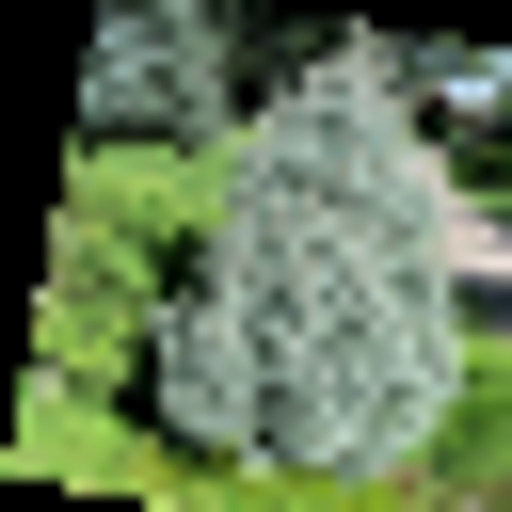

In [7]:
Image.fromarray(train_X[3788]).resize((512,512))

In [4]:
print(train_y[1])

11


In [3]:

transform = T.Compose([
     T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.2, hue=0.0),
     T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2),
                    shear=5),
])



In [ ]:
Image.fromarray((transform(torch.Tensor(train_X[50]).permute(2, 0, 1)/255.).\
                 permute(1, 2, 0).numpy()*255.).astype(np.uint8)).\
                 resize((256, 256))

In [ ]:
# Применяем трансформации ко всем изображениям train_X
for i in range(len(train_X)):
    img_tensor = transform(torch.Tensor(train_X[i]).permute(2, 0, 1) / 255.)  # Преобразуем в тензор и нормализуем
    train_X[i] = (img_tensor.permute(1, 2, 0).numpy() * 255.).astype(np.uint8)  # Записываем обратно в train_X

# Применяем трансформации ко всем изображениям test_X
# for i in range(len(test_X)):
#     img_tensor = transform(torch.Tensor(test_X[i]).permute(2, 0, 1) / 255.)
#     test_X[i] = (img_tensor.permute(1, 2, 0).numpy() * 255.).astype(np.uint8)  # Записываем обратно в test_X

In [5]:


# Сохранение массивов в файлы
np.save('train_X.npy', train_X)
np.save('train_y.npy', train_y)
np.save('test_X.npy', test_X)
np.save('test_y.npy', test_y)

In [5]:
import numpy as np

# Загрузка данных
train_X = np.load('train_X.npy')
train_y = np.load('train_y.npy')
test_X = np.load('test_X.npy')
test_y = np.load('test_y.npy')

In [ ]:
Image.fromarray(train_X[3]).resize((512,512))

##Создание Pytorch DataLoader'a

In [ ]:

batch_size = 128
dataloader = {}
for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    tensor_x = torch.Tensor(X)
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                                     num_classes=len(CLASSES))/1.
    dataset = TensorDataset(tensor_x, tensor_y) # создание объекта датасета
    dataloader[part] = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=3) # создание экземпляра класса DataLoader
dataloader

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Normalize(nn.Module):
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        self.mean = torch.tensor(mean).to(device)
        self.std = torch.tensor(std).to(device)

    def forward(self, input):
        x = input / 255.0
        x = x - self.mean
        x = x / self.std
        return x.permute(0, 3, 1, 2) # nhwc -> nm

model = torch.hub.load("chenyaofo/pytorch-cifar-models",
                       #"cifar100_mobilenetv2_x0_5",
                       'cifar100_resnet20',
                       pretrained=True)
model.to(device)
new_model = nn.Sequential(
    Normalize([0.5074,0.4867,0.4411],[0.2011,0.1987,0.2025]),# https://blog.jovian.ai/image-classification-of-cifar100-dataset-using-pytorch-8b7145242df1
    model
).to(device)
print(new_model(torch.rand(1, 32, 32, 3).to(device)))
# summary(new_model, input_size=(32, 32, 3))
new_model

In [ ]:
## mobilenetv2
#in_features = new_model[1].classifier[1].in_features
#new_model[1].classifier[1] = nn.Linear(in_features=in_features,
#                                       out_features=len(CLASSES),
#                                       bias=True)
## resnet20
in_features = new_model[1].fc.in_features
new_model[1].fc = nn.Linear(in_features=in_features,
                            out_features=len(CLASSES),
                            bias=True)

new_model.to(device)
summary(new_model, input_size=(32, 32, 3))
print(new_model(torch.rand(1, 32, 32, 3).to(device)))

# Заморозка весов

In [ ]:
print("Обучаемые параметры:")
keep_last = 14
total = len([*new_model.named_parameters()])
params_to_update = []
for i, (name, param) in enumerate(new_model.named_parameters()):
    if i < total - keep_last:
        param.requires_grad = False
    else:
        params_to_update.append(param)
        param.requires_grad = True
        print("\t",name)
summary(new_model, input_size=(32, 32, 3))

# Fine tunning

In [12]:
# добавляем сглаживание целевых меток, это увеличит значение функции потерь
# но полученная модель будет более устойчивой к выбросам в обучающей выборке
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# используется SGD c momentum и L2-регуляризацией весов
optimizer = optim.SGD(params_to_update, lr=0.01, momentum=0.9,
                      weight_decay=1e-5)
# добавляем постепенное уменьшение шага обучения каждые 20 эпох
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

In [ ]:
EPOCHS = 12
REDRAW_EVERY = 10
steps_per_epoch = len(dataloader['train'])
steps_per_epoch_val = len(dataloader['test'])
# NEW
pbar = tqdm(total=EPOCHS*steps_per_epoch)
losses = []
losses_val = []
passed = 0
# для создания чекпоинта
best_acc = 0
checkpoint_path = 'cifar_cnn_fine.pth'
for epoch in range(EPOCHS):  # проход по набору данных несколько раз
    tmp = []
    print(epoch)
    new_model.train()
    for i, batch in enumerate(dataloader['train'], 0):
        # получение одного минибатча; batch это двуэлементный список из [inputs, labels]
        inputs, labels = batch
        # на GPU
        inputs, labels = inputs.to(device), labels.to(device)

        # очищение прошлых градиентов с прошлой итерации
        optimizer.zero_grad()

        # прямой + обратный проходы + оптимизация
        outputs = new_model(inputs)
        loss = criterion(outputs, labels)
        #loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()

        # для подсчёта статистик
        accuracy = (labels.detach().argmax(dim=-1)==outputs.detach().argmax(dim=-1)).\
                    to(torch.float32).mean().cpu()*100
        tmp.append((loss.item(), accuracy.item()))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    scheduler.step() # обновляем learning_rate каждую эпоху
    tmp = []
    new_model.eval()
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            # на GPU
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = new_model(inputs)
            loss = criterion(outputs, labels)
            accuracy = (labels.argmax(dim=-1)==outputs.argmax(dim=-1)).\
                        to(torch.float32).mean().cpu()*100
            tmp.append((loss.item(), accuracy.item()))
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))
    # сохранение чекпоинта
    acc = losses_val[-1][0][1]
    print("acc =", acc, "best_acc = ", best_acc)
    if acc > best_acc:
        best_acc = acc
        torch.save(new_model.state_dict(), checkpoint_path)
    # обновление графиков
    if (epoch+1) % REDRAW_EVERY != 0:
        continue
    clear_output(wait=False)
    print('Эпоха: %s\n'
          'Лучшая доля правильных ответов: %s\n'
          'Текущая доля правильных ответов: %s' % (epoch+1, best_acc, acc))
    passed += pbar.format_dict['elapsed']
    pbar = tqdm(total=EPOCHS*steps_per_epoch, miniters=5)
    pbar.update((epoch+1)*steps_per_epoch)
    x_vals = np.arange(epoch+1)
    _, ax = plt.subplots(1, 2, figsize=(15, 5))
    stats = np.array(losses)
    stats_val = np.array(losses_val)
    ax[1].set_ylim(stats_val[:, 0, 1].min()-5, 100)
    ax[1].grid(axis='y')
    for i, title in enumerate(['CCE', 'Accuracy']):
        ax[i].plot(x_vals, stats[:, 0, i], label='train')
        ax[i].fill_between(x_vals, stats[:, 1, i],
                           stats[:, 2, i], alpha=0.4)
        ax[i].plot(x_vals, stats_val[:, 0, i], label='val')
        ax[i].fill_between(x_vals,
                           stats_val[:, 1, i],
                           stats_val[:, 2, i], alpha=0.4)
        ax[i].legend()
        ax[i].set_title(title)
    plt.show()
new_model.load_state_dict(torch.load(checkpoint_path))
print('Обучение закончено за %s секунд' % passed)

In [ ]:

batch_size = 64
dataloader = {}
for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    tensor_x = torch.Tensor(X)
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                                     num_classes=len(CLASSES))/1.
    dataset = TensorDataset(tensor_x, tensor_y) # создание объекта датасета
    dataloader[part] = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=3) # создание экземпляра класса DataLoader
dataloader

In [15]:
for part in ['train', 'test']:
    y_pred = []
    y_true = []
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader[part], 0):
            inputs, labels = data
             # на GPU
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = new_model(inputs).detach().cpu().numpy()
            y_pred.append(outputs)
            y_true.append(labels.cpu().numpy())
        y_true = np.concatenate(y_true)
        y_pred = np.concatenate(y_pred)
        print(part)
        # print("$$$$$$$$$", len(y_true))
        # print("$$$$$$$$$", len(y_pred))
        # print("$$$$$$$$$",list(map(str, CLASSES)))
        print(classification_report(y_true.argmax(axis=-1), y_pred.argmax(axis=-1),
                                    digits=4, target_names=list(map(str, CLASSES))))
        print('-'*50)

train
                    precision    recall  f1-score   support

              алоэ     0.9986    0.9314    0.9638      3762
          бархатцы     0.9091    0.9924    0.9489      3536
           вербена     0.9738    0.9294    0.9511      3796
            герань     0.9743    0.9655    0.9699      3534
           гиацинт     0.9749    0.9771    0.9760      4019
          глициния     0.9583    0.9550    0.9567      3804
декоративная трава     0.9753    0.9779    0.9766      3713
               дуб     0.8936    0.9365    0.9146      3938
               ель     0.9931    0.9113    0.9504      3955
         жимолость     0.9155    0.9399    0.9275      3527
              ирис     0.9884    0.9681    0.9781      3975
            кактус     0.9730    0.9570    0.9649      3951
          клематис     0.8588    0.9754    0.9134      3985
              клен     0.9223    0.9319    0.9271      4142
            космея     0.9867    0.8852    0.9332      3762
             лилии     0.9739    

In [ ]:
# сохраниение модели
# ПЕРВЫЙ СПОСОБ: сохранение параметров
PATH = 'cifar_cnn_fine.pth'
torch.save(new_model.state_dict(), PATH)

# ВТОРОЙ СПОСОБ: сохранение всей архитектуры
PATH2 = 'cifar_cnn_fine.pt'
torch.save(new_model, PATH2)
# загрузка
new_model_2 = torch.load(PATH2)
new_model_2.eval()

In [17]:
# входной тензор для модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x = torch.randn(1, 32, 32, 3, requires_grad=True).to(device)
torch_out = new_model(x)

# экспорт модели
torch.onnx.export(new_model,               # модель
                  x,                   # входной тензор (или кортеж нескольких тензоров)
                  "cifar100_5.onnx", # куда сохранить (либо путь к файлу либо fileObject)
                  export_params=True,  # сохраняет веса обученных параметров внутри файла модели
                  opset_version=9,     # версия ONNX
                  do_constant_folding=True,  # следует ли выполнять укорачивание констант для оптимизации
                  input_names = ['input'],   # имя входного слоя
                  output_names = ['output'],  # имя выходного слоя
                  dynamic_axes={'input' : {0 : 'batch_size'},    # динамичные оси, в данном случае только размер пакета
                                'output' : {0 : 'batch_size'}})